# İş Akışı ve Hiperparametre Optimizasyonu

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

🏠 Ev fiyatları veri setini içe aktarın. Basitlik adına sadece sayısal özellikleri tutacağız

🎯 Hedefiniz en iyi KNN Regressor'ı yerleştirmek olacak. Özellikle, ev fiyatlarınız için en iyi tahminleri elde etmek üzere kaç tane "komşu" (<font color=blue>K</font>NN'deki <font color=blue>K</font>) göz önünde bulundurmalısınız?

In [2]:
# Load raw data
data = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/houses_train_raw.csv', index_col="Id")

# Only keep numerical columns and raws without NaN
data = data.select_dtypes(include=np.number).dropna()

data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


In [3]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

## 1. Eğitim/Test Ayrımı

❓ **Soru (Holdout)**❓

👇 `X_train`, `X_test`, `y_train` ve `y_test` oluşturmak için veri setini böl. Şunları kullan:
- `test_size=0.3`
- Sonuçlarınızı arkadaşınızla karşılaştırmak için `random_state=0`

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split ( X, y, test_size = 0.3, random_state = 0)

## 2. Ölçeklendirme

⚖️ Ölçeklendirme KNN algoritması için her zaman kritik derecede önemlidir..

❓ **Soru (Ölçeklendirme)** ❓ 

* Eğitim setinizi ve test setinizi ölçeklendirin.
* Burada, basitçe `StandardScaler` uygulayalım ve özellik başına bir ölçekleyici seçerek zaman kaybetmeyelim. Gerçekten de, bu egzersizin amaçları şunlardır:
    * KNN'i gözden geçirmek
    * GridSearchCV'yi anlamak
    * RandomizedSearchCV'yi anlamak

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Temel KNN modeli

❓ **Soru (KNN için bir temel)** ❓

Sadece _en yakın komşuyu_ dikkate alan basit bir KNN regressor'ı çapraz doğrulayın (*cv = 5*) ve 5 kat üzerindeki ortalama skoru hesaplayın.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

knn= KNeighborsRegressor(n_neighbors = 1)
cv = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()

print(f"Cross-validation score for KNN with 1 neighbor: {cv:.4f}")

Cross-validation score for KNN with 1 neighbor: 0.5602


## 4. GridSearch

### 4.1. İlk GridSearch

❓ **Soru (GridSearch v1)**❓

En iyi KNN hiperparametresini `n_neighbors` bulmak için SKLearn `GridSearchCV` kullanalım.
- `n_neighbors` = [1,5,10,20,50] ile kaba taneli bir yaklaşım başlat
- Her parametreyi 5-kat çapraz doğrula
- `n_jobs` kullanarak performans sürenizi maksimize ettiğinizden emin olun

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Instantiate model
knn = KNeighborsRegressor()

# Hyperparameter Grid
param_grid = {'n_neighbors': [1, 5, 10, 20, 50]}

# Instantiate Grid Search
grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)

# Fit data to Grid Search
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 5, 10, 20, 50]})

❓ **Soru (en iyi parametreler)** ❓

GridSearch'e göre, optimal K değeri nedir?

In [8]:
grid_search.best_params_

{'n_neighbors': 10}

❓ **Soru (puanlama)** ❓ Optimal K değerinin ürettiği en iyi skor nedir?

In [9]:
grid_search.best_score_

0.7596697382171873

### 4.2. İkinci GridSearch

❓ **Soru (GridSearch V2)** ❓

Şimdi, en iyi $K$'nın nerede olduğu hakkında bir fikrimiz var, ancak denemediğimiz bazı değerler daha iyi bir performansla sonuçlanabilir.

* Önceki en iyi değerinizin çevresindeki $K$ için bazı değerleri deneyerek GridSearch'ü yeniden çalıştırın
* Bu rafine edilmiş GridSearch için `best_score` ve `best_k` nelerdir?

In [20]:
# Instantiate model
knn = KNeighborsRegressor()

# Hyperparameter Grid
param_grid = {'n_neighbors': [12, 14, 16, 18, 20, 22]}

# Instantiate Grid Search
grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)

# Fit data to Grid Search
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"Best number of neighbors: {best_k}")


Best number of neighbors: 16


In [22]:
best_score = grid_search.best_score_
print(f"Best cross-validation score: {best_score:.4f}")

Best cross-validation score: 0.7666


***🧪 Kodunuzu test edin***

In [23]:
from nbresult import ChallengeResult
result = ChallengeResult('knn',
                         best_k=best_k,
                         best_score=best_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/didemarslan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/didemarslan/reading_the_green_line/S16D1-S-data-knn/S16D3-S-data-electrocardiograms/S16D3-S-data-threshold/S16D4-S-loss-functions/S16D4-S-data-solvers/S16D4-S-gradient-descent/D16D5-S-data-workflow/tests
plugins: dash-4.4.1, langsmith-0.12.4, typeguard-4.4.2, anyio-4.15.1
collecting ... collected 2 items

test_knn.py::TestKnn::test_best_k PASSED                                 [ 50%]
test_knn.py::TestKnn::test_best_score PASSED                             [100%]

============================== 2 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/knn.pickle

git commit -m 'Completed knn step'

git push origin master



### 4.3. Görsel kontrol (manuel GridSearch)

☝️ Bu problem aslında manuel olarak GridSearch yapmak için yeterince basittir.

❓ **Soru(Manuel GridSearch)** ❓

- $K$'nın $1$'den $50$'ye kadar tüm değerleri üzerinde manuel olarak döngü yapın ve her modelin çapraz doğrulanmış skorlarının ortalamasını bir listede saklayın.
- `Dirsek Yöntemi` kullanarak en iyi $K$'yı görsel olarak bulmak için skorları $K$'nın bir fonksiyonu olarak çizin

<Axes: title={'center': 'Cross-validation score for different k values'}, xlabel='Number of neighbors (k)', ylabel='Cross-validation score'>

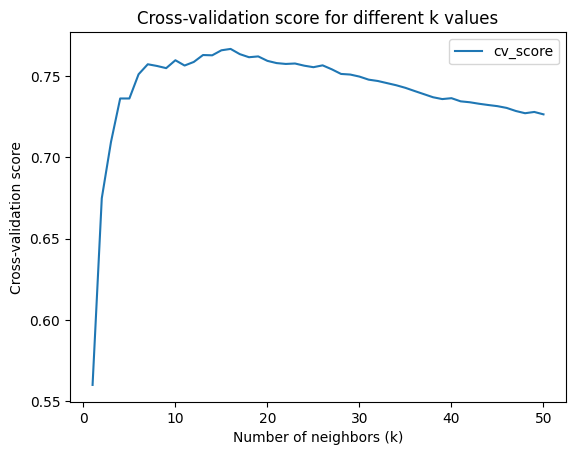

In [ ]:
scores = []

for k in range(1, 51):
    knn = KNeighborsRegressor(n_neighbors = k)
    cv_loop = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()
    scores.append(cv_loop)

pd.DataFrame({'k': range(1, 51), 'cv_score': scores}).set_index('k').plot(title='Cross-validation score for different k values', ylabel='Cross-validation score', xlabel='Number of neighbors (k)')


❓GridSearchCV'yi böyle bir manuel döngüden daha iyi bir seçenek yapan şeyi tahmin edebilir misiniz?

<details>
    <summary>Cevap</summary>

- Sklearn'ın `n_jobs=-1` seçeneği aramayı paralelleştirmenize izin verir, tüm CPU çekirdeklerinizi kullanır
- Birlikte optimize edilecek birden fazla hiperparametreniz olsaydı ne olurdu?
</details>

## 5. Birden çok parametre ile GridSearch

👩🏻‍🏫 KNNRegressor, `p` hiperparametresi aracılığıyla çeşitli _mesafe metrikleri_ destekler

📚 [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

❓ **Soru (birden çok parametreyi ayarlama)** ❓

* En iyi $K$ ve $p$'yi aynı anda aramak için GridSearchCV kullanın.
    * $K = [1, 5, 10, 20, 50]$ ve $p = [1, 2, 3]$ için tüm kombinasyonları deneyin.

In [25]:
knn = KNeighborsRegressor()
param_grid = {'n_neighbors': [1, 5, 10, 20, 50], 'p': [1, 2, 3]}
grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 5, 10, 20, 50], 'p': [1, 2, 3]})

❓ **Soru (alt model sayısı)**❓

Toplamda kaç alt model eğittiniz?

<details>
    <summary>İpucu</summary>

15'ten çok daha fazla. İki kez düşün :)
    <details>
    <summary>Cevap</summary>

CV=5 nedeniyle 75 model
</details>

❓ **Soru (modeli birden çok parametre ile ayarladıktan sonra en iyi parametreler ve en iyi skor)**❓

*En iyi parametreler* ve *en iyi skor* nedir?

In [26]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

Best parameters: {'n_neighbors': 10, 'p': 1}
Best cross-validation score: 0.7969


## 6. Rastgele Arama

Şimdi bir RandomizedSearch'ün aynı sayıda model yerleştirilerek daha iyi bir kombinasyon bulup bulamayacağını görelim.

❓ **Soru (RandomizedSearchCV)** ❓

`RandomizedSearchCV` kullanarak
- $K$'yı uniform `scipy.stats.randint(1,50)` ([döküman](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html)) dağılımından rastgele örnekle
- $p$'yi $[1,2,3]$ listesinden örnekle
- Önceki GridSearchCV'nizdeki ile tam olarak aynı sayıda model yerleştirmek için doğru `n_iter` ve `cv` sayılarını kullanın.

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

knn = KNeighborsRegressor()
param_dist = {'n_neighbors': randint(1, 50), 'p': [1, 2, 3]}
random_search = RandomizedSearchCV(knn, param_dist, n_iter=15, cv=5, n_jobs=-1, random_state=0)
random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(), n_iter=15, n_jobs=-1,
                   param_distributions={'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x14a591ca0>,
                                        'p': [1, 2, 3]},
                   random_state=0)

In [28]:
best_params = random_search.best_params_
best_score = random_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

Best parameters: {'n_neighbors': 10, 'p': 1}
Best cross-validation score: 0.7969


## 7. Genelleme

❓ **Soru (modelinizi bir kez daha ince ayarlama)**❓

- İsterseniz RandomsearchCV'nizi rafine edin
- En iyi modelinizi seçin

In [29]:
knn = KNeighborsRegressor()
param_dist = {'n_neighbors': randint(5, 15), 'p': [1, 2, 3]}
random_search = RandomizedSearchCV(knn, param_dist, n_iter=25, cv=5, n_jobs=-1, random_state=0)
random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(), n_iter=25, n_jobs=-1,
                   param_distributions={'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x146282270>,
                                        'p': [1, 2, 3]},
                   random_state=0)

In [ ]:
best_score = random_search.best_score_
print(f"Best cross-validation score: {best_score:.4f}")

Best cross-validation score: 0.7975


Şimdi `cv_results`'ınızı bir `DataFrame` olarak görüntülemeye çalışın, bu CV'nin içinde neler olup bittiğini görselleştirmenize yardımcı olacak! 😉

In [32]:
pd.DataFrame(random_search.cv_results_).sort_values(by='mean_test_score', ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,0.000423,0.000120,0.002343,0.000816,9,1,"{'n_neighbors': 9, 'p': 1}",0.762593,0.823336,0.741549,0.867283,0.792639,0.797480,0.044519,1
0,0.000551,0.000133,0.002481,0.000282,10,1,"{'n_neighbors': 10, 'p': 1}",0.764654,0.821320,0.733358,0.866147,0.799148,0.796926,0.045769,2
3,0.000443,0.000124,0.001633,0.000101,7,1,"{'n_neighbors': 7, 'p': 1}",0.736660,0.817465,0.757978,0.867009,0.795878,0.794998,0.045749,3
22,0.000491,0.000165,0.002090,0.000928,7,1,"{'n_neighbors': 7, 'p': 1}",0.736660,0.817465,0.757978,0.867009,0.795878,0.794998,0.045749,3
21,0.000413,0.000171,0.002185,0.000956,7,1,"{'n_neighbors': 7, 'p': 1}",0.736660,0.817465,0.757978,0.867009,0.795878,0.794998,0.045749,3
14,0.000338,0.000147,0.001640,0.000715,8,1,"{'n_neighbors': 8, 'p': 1}",0.750651,0.825437,0.742715,0.866525,0.785850,0.794236,0.046527,6
23,0.000454,0.000148,0.001924,0.000879,5,1,"{'n_neighbors': 5, 'p': 1}",0.695777,0.817846,0.759819,0.867212,0.823164,0.792764,0.059309,7
17,0.000340,0.000122,0.001781,0.000571,12,1,"{'n_neighbors': 12, 'p': 1}",0.761157,0.813126,0.732005,0.856813,0.790195,0.790659,0.042876,8
5,0.000434,0.000185,0.002511,0.000962,13,1,"{'n_neighbors': 13, 'p': 1}",0.762578,0.813153,0.731283,0.852001,0.785801,0.788963,0.041454,9
19,0.000457,0.000137,0.002543,0.000940,14,1,"{'n_neighbors': 14, 'p': 1}",0.758705,0.812448,0.727145,0.851217,0.777336,0.785370,0.042976,10


In [33]:
random_search.best_estimator_
print(f"Best estimator: {random_search.best_estimator_}")

Best estimator: KNeighborsRegressor(n_neighbors=9, p=1)


❓ **Soru ("En iyi" modelin değerlendirmesi)** ❓

* "En iyi parametrelerle" modelimizin **görülmemiş** test seti `X_test` üzerindeki performansını keşfetme zamanı geldi.
    * Test seti için r2 skorunu hesaplayın ve `r2_test` olarak kaydedin.

In [36]:
from sklearn.metrics import r2_score

r2_test = r2_score(y_test, random_search.predict(X_test_scaled))
print(f"R^2 score on test set: {r2_test:.4f}")

R^2 score on test set: 0.7718


❓ **Soru (Bir adım geri çekilme)** ❓

Optimize edilmiş modelin iyi genelleme yaptığını düşünür müsünüz?

<details><summary>Cevap</summary>

Test skoru eğitim seti ile biraz azalabilir. Muhtemelen %5'ten fazla değil. Bunun nedeni şunlar olabilir:
- Temsili olmayan bir eğitim/test bölünmesi
- Model ayarlama aşamasında aşırı öğrenmeye yol açan çok küçük bir çapraz doğrulama sayısı. Ne kadar çok çapraz doğrulama yaparsanız, bulgularınız o kadar güçlü genelleşir - ancak veri setiniz çok küçükse cv'yi çok fazla artıramazsınız çünkü her katmanda temsili olmak için yeterli gözlemi tutamazsınız.
- Veri setimiz çok küçük ve hiperparametre optimizasyonumuz bu nedenle eğitim/test bölünmemize son derece bağımlı (ve aşırı uyum gösteriyor). Veri setinizin denediğiniz toplam hiperparametre kombinasyonu sayısından çok daha büyük olduğundan her zaman emin olun!
    
</details>

***🧪 Kodunuzu test edin***

In [ ]:
from nbresult import ChallengeResult
result = ChallengeResult('r2',
                         r2_test=r2_test)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/didemarslan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/didemarslan/reading_the_green_line/S16D1-S-data-knn/S16D3-S-data-electrocardiograms/S16D3-S-data-threshold/S16D4-S-loss-functions/S16D4-S-data-solvers/S16D4-S-gradient-descent/D16D5-S-data-workflow/tests
plugins: dash-4.4.1, langsmith-0.12.4, typeguard-4.4.2, anyio-4.15.1
collecting ... collected 1 item

test_r2.py::TestR2::test_r2 PASSED                                       [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/r2.pickle

git commit -m 'Completed r2 step'

git push origin master



🏁 Tebrikler! Artık GridSearchCV veya RandomizedSearchCV kullanarak bir modeli nasıl ince ayarlayacağınızı biliyorsunuz

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki meydan okumaya geçin!